In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../../CONCERT/src')

In [3]:
sys.path.append('../scripts')

In [4]:
from concert_map import CONCERT

In [5]:
import os
import torch
import scanpy as sc
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#Some auxiliary functions
def pairwise_distance_quantile_numpy(loc, quantile=0.1):
    # Compute condensed pairwise distance matrix (1D array of upper triangle)
    dists = pdist(loc, metric='euclidean')  # shape: (N * (N - 1) / 2,)

    # Compute quantile
    q = np.quantile(dists, quantile)

    return q

def str_list_to_unique_index(str_list):
        original_numbers = np.array([sum(ord(char) for char in s) for s in str_list])
        renumbered = {num: idx + 1 for idx, num in enumerate(sorted(set(original_numbers)))}
        new_numbers = [renumbered[num] for num in original_numbers]
        return np.array(new_numbers)

In [7]:
data_mat = h5py.File('/data2/a330d/GSM5808054_data.h5', 'r')
x = np.array(data_mat['X']).astype('float32') # count matrix
loc = np.array(data_mat['pos']).T.astype('float32') # location information
perturbation_ = np.array(data_mat['perturbation']).astype('str') # perturbation + tissue info, need to dicipher
pert_values = ['Jak2', 'Tgfbr2', 'Ifngr2']
#revalue perturbation for better understanding
tissue_ = perturbation_.copy()
tissue_ = np.array(['KP' if t in pert_values else t for t in tissue_])
tissue_ = np.array(['tumor' if t == 'KP' else t for t in tissue_])
tissue_ = np.array(['normal' if t == 'None' else t for t in tissue_])
tissue = str_list_to_unique_index(tissue_) - 1
unique_values = [val for val in pert_values if val in perturbation_]
mapping = {val: idx + 1 for idx, val in enumerate(unique_values)}
perturbation = np.vectorize(lambda x: mapping.get(x, 0))(perturbation_)
cell_atts = np.concatenate((tissue[:, None], perturbation[:, None]), axis=1)
sample_indices = torch.tensor(np.arange(x.shape[0]), dtype=torch.int)
num_classes = len(np.unique(perturbation))
batch = np.eye(num_classes)[perturbation].astype('float32')
n_batch = batch.shape[1]
data_mat.close()

print(np.unique(tissue_, return_counts=True))
print(np.unique(perturbation, return_counts=True))

tissue_dic = {tissue_[i]: tissue[i] for i in range(len(tissue_))}
pert_dic = mapping
print("tissue_dic", tissue_dic)
print("pert_dic", pert_dic)

(array(['normal', 'periphery', 'tumor'], dtype='<U9'), array([1425,  149,  329]))
(array([0, 1, 2]), array([1807,   21,   75]))
tissue_dic {np.str_('normal'): np.int64(1), np.str_('tumor'): np.int64(0), np.str_('periphery'): np.int64(2)}
pert_dic {'Jak2': 1, 'Tgfbr2': 2}


In [8]:
if x.shape[0] <= 1024:
    batch_size = 128
elif x.shape[0] <= 2048:
    batch_size = 256
else:
    batch_size = 512

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
loc_range = 20
loc = scaler.fit_transform(loc) * loc_range
loc_dim = loc.shape[1]
cutoff = np.ones(loc.shape[0], dtype=np.float32) * 0.5
print(f"cutoff: {cutoff}")
loc = np.concatenate((loc, batch), axis=1)

# set learnable scales per dimensionanlity of kernel and per perturbation
kernel_scale = 10
kernel_scale = np.array([[kernel_scale] * loc_dim] * n_batch) 
print(f"Initial kernel scales {kernel_scale}")
print(f"Initial kernel scale shapes {kernel_scale.shape}")

cutoff: [0.5 0.5 0.5 ... 0.5 0.5 0.5]
Initial kernel scales [[10 10]
 [10 10]
 [10 10]]
Initial kernel scale shapes (3, 2)


In [10]:
eps = 1e-5
inducing_point_steps = 6
initial_inducing_points = np.mgrid[0:(1+eps):(1./inducing_point_steps), 0:(1+eps):(1./inducing_point_steps)].reshape(2, -1).T * loc_range
print(initial_inducing_points.shape)
## add one-hot batch matrix for batch 0
initial_inducing_points_1 = np.zeros((initial_inducing_points.shape[0], n_batch))
initial_inducing_points_1[:, 0] = 1
initial_inducing_points = np.concatenate((initial_inducing_points, initial_inducing_points_1), axis=1)

(49, 2)


In [49]:
from preprocess import normalize
adata = sc.AnnData(x, dtype="float32")
adata = normalize(adata,size_factors=True,normalize_input=True,logtrans_input=True)

/data/a330d/projects/cellina-reproducibility/notebooks/../../CONCERT/src/preprocess.py:53: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata)
/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(


In [16]:
from concert_map import CONCERT
Normal_dim = 8
GP_dim = 2
encoder_layers = [128, 64]
decoder_layers = [128]
noise = 0.25
dropoutE = 0
dropoutD = 0
KL_loss = 0.025
init_beta = 10
min_beta = 5
max_beta = 25
device = "cuda"

model = CONCERT(cell_atts=cell_atts, num_genes=adata.n_vars, encoder_dim=256, GP_dim=GP_dim, Normal_dim=Normal_dim, n_batch=n_batch, encoder_layers=encoder_layers, decoder_layers=decoder_layers,
        noise = 0.25, encoder_dropout=dropoutE, decoder_dropout=dropoutD, shared_dispersion=False,
        fixed_inducing_points=True, initial_inducing_points=initial_inducing_points, 
        fixed_gp_params=False, kernel_scale=kernel_scale, multi_kernel_mode=True,
        N_train=adata.n_obs, KL_loss=KL_loss, dynamicVAE=True, init_beta=init_beta, min_beta=min_beta, max_beta=max_beta, 
        mask_cutoff=cutoff, dtype=torch.float32, device=device)

In [74]:
loc.shape, adata.X.shape, adata.raw.X.shape, adata.obs.size_factors.shape

((1903, 5), (1903, 2000), (1903, 2000), (1903,))

In [18]:
from time import time
t0 = time()
num_samples = 1
weight_decay = 1e-6
lr = 1e-4
train_size = 0.95
maxiter = 50
patience = maxiter // 2
model_file = 'model.pt'

model.train_model(pos=loc, ncounts=adata.X, raw_counts=adata.raw.X, size_factors=adata.obs.size_factors, batch=batch,
                lr=lr, weight_decay=weight_decay, batch_size=batch_size, num_samples=num_samples,
                train_size=train_size, maxiter=maxiter, patience=patience, save_model=True, model_weights=model_file)

print('Training time: %d seconds.' % int(time() - t0))

Training time: 12 seconds.


In [38]:
data_mat = h5py.File('/data2/a330d/GSM5808054_data.h5', 'r')
genes = np.array(data_mat['gene'], dtype=str)
data_mat.close()

In [39]:
denoised_counts, _ = model.batching_denoise_counts(X=loc, sample_index=sample_indices, cell_atts=cell_atts, batch_size=batch_size, n_samples=25)

/data/a330d/projects/cellina-reproducibility/notebooks/../../CONCERT/src/concert_map.py:371: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  idx_t = torch.tensor(sample_index, dtype=torch.int)


In [64]:
pert_ind = [0]
target_cell_tissue = 'tumor'
target_cell_perturbation = 'Jak2'
perturbed_counts, pert_cell_att = model.counterfactualPrediction(X=loc, sample_index=sample_indices, cell_atts=cell_atts, batch_size=batch_size, n_samples=25, perturb_cell_id = pert_ind, 
                                                      target_cell_tissue = tissue_dic[target_cell_tissue], target_cell_perturbation = pert_dic[target_cell_perturbation])

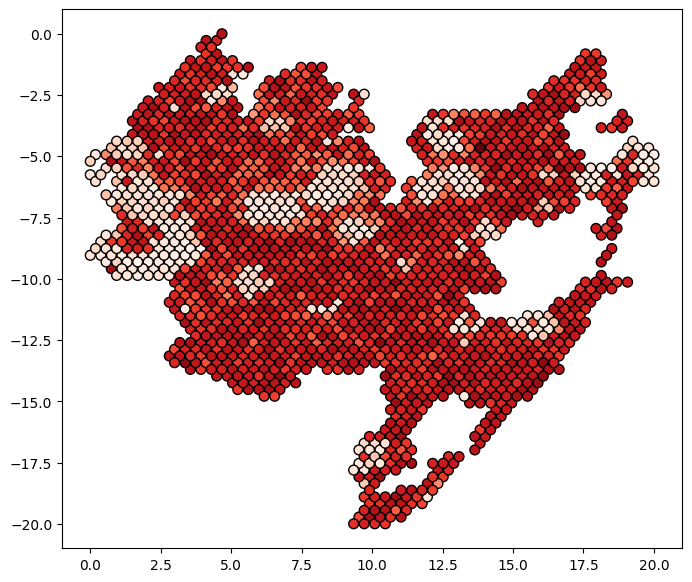

In [42]:
plt.figure(figsize=(8, 7))
gex = denoised_counts[:, 4]
plt.scatter(loc[:,1], -loc[:,0], c=gex, cmap='Reds', edgecolor='k', s=50)

# Custom training

In [7]:
adata = sc.read(
    "/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202.h5ad",
    backup_url="https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

/data/a330d/miniforge3/envs/concert/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [8]:
x = 0.02
n_cells = adata.n_obs
n_subsample = int(n_cells * x)
# Randomly choose cell indices
np.random.seed(42)  # for reproducibility
subsample_idx = np.random.choice(n_cells, n_subsample, replace=False)
# Create the subsampled AnnData
adata = adata[subsample_idx].copy()

In [9]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

In [10]:
import squidpy as sq

n_neighbors = 50
sq.gr.spatial_neighbors(adata, n_neighs=n_neighbors)

/data/a330d/miniforge3/envs/concert/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data/a330d/miniforge3/envs/concert/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/data/a330d/miniforge3/envs/concert/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [11]:
from cellina._spatial_utils import spatial_neighbors
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [12]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'][:,0].toarray().astype(np.float32)

In [13]:
from scipy.sparse import csr_matrix

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.obsm['spatial_x'] = adata.obsp['spatial_connectivities'] @ adata.X / n_neighbors
# float32
adata.obsm['spatial_x'] = csr_matrix(adata.obsm['spatial_x']).astype(np.float32)

## Data splits

In [14]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    is_non_epi = adata.obs["coarse_type"] != "Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_non_epi)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [15]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [16]:
# ...existing code...
# coordinates: use spatial coordinates stored in adata.obsm['spatial']
loc_coords = np.asarray(adata.obsm['spatial']).astype('float32')
# scale coords to the same loc_range used previously
from sklearn.preprocessing import MinMaxScaler
from preprocess import normalize

scaler_sp = MinMaxScaler()
loc_range = 20
loc_coords = scaler_sp.fit_transform(loc_coords) * loc_range
loc_dim = loc_coords.shape[1]

# Recompute masks as before
train_mask = (~adata.obs['is_holdout'].astype(bool)).values
test_mask  = (adata.obs['is_holdout'].astype(bool)).values
print("train/test counts:", train_mask.sum(), test_mask.sum())

# map tissue regions (obs.typ) -> contiguous codes across full adata
tissue_names = adata.obs['typ'].astype(str).values
unique_tissues = np.unique(tissue_names)
tissue_name_to_code = {name: i for i, name in enumerate(sorted(unique_tissues))}
tissue_code_full = np.array([tissue_name_to_code[s] for s in tissue_names], dtype=int)

# use obs.sid as batch/perturbation codes
sid_vals = adata.obs['sid'].astype(str).values
unique_sids = np.unique(sid_vals)
sid_to_code = {s: i for i, s in enumerate(sorted(unique_sids))}
batch_code_full = np.array([sid_to_code[s] for s in sid_vals], dtype=int)

# map cell types to codes
ct_vals = adata.obs['coarse_type'].astype(str).values
unique_cts = np.unique(ct_vals)
ct_to_code = {c: i for i, c in enumerate(sorted(unique_cts))}
ct_code_full = np.array([ct_to_code[c] for c in ct_vals], dtype=int)

# full cell attributes (tissue, batch)
print(tissue_code_full.shape, batch_code_full.shape, ct_code_full.shape)
cell_atts_full = np.stack([tissue_code_full, batch_code_full, ct_code_full], axis=1).astype(int)
n_batch_full = len(np.unique(batch_code_full))
batch_full = np.eye(n_batch_full, dtype='float32')[batch_code_full]

# build pos arrays (coords + batch one-hot) for train/test
pos_train = np.concatenate((loc_coords[train_mask], batch_full[train_mask]), axis=1).astype('float32')
pos_test  = np.concatenate((loc_coords[test_mask],  batch_full[test_mask]),  axis=1).astype('float32')

# new cutoff aligned with loc_coords (use for training subset)
cutoff_full = np.ones(loc_coords.shape[0], dtype=np.float32) * 0.5

# prepare training AnnData and other slices (unchanged)
adata_train = adata[train_mask].copy()
adata_train.X = adata_train.X.astype('float32')
adata_train = normalize(adata_train, size_factors=True, normalize_input=True, logtrans_input=True)

sample_indices_train = torch.arange(adata_train.n_obs, dtype=torch.int)
sample_indices_test  = torch.arange(pos_test.shape[0], dtype=torch.int)

cell_atts_train = cell_atts_full[train_mask].astype(int)
cell_atts_test  = cell_atts_full[test_mask].astype(int)

# rebuild kernel_scale & inducing points to match loc_dim and n_batch_full
kernel_scale_scalar = 10.0
kernel_scale_re = np.array([[kernel_scale_scalar] * loc_dim] * n_batch_full, dtype=float)

inducing_point_steps = 6
eps = 1e-5
initial_inducing_points_re = np.mgrid[0:(1+eps):(1./inducing_point_steps), 0:(1+eps):(1./inducing_point_steps)].reshape(2, -1).T * loc_range
initial_inducing_points_batch = np.zeros((initial_inducing_points_re.shape[0], n_batch_full), dtype=float)
initial_inducing_points_batch[:, 0] = 1.0
initial_inducing_points_re = np.concatenate((initial_inducing_points_re, initial_inducing_points_batch), axis=1).astype('float32')

# Sanity checks
print("pos_train.shape:", pos_train.shape, "inducing_point dim:", initial_inducing_points_re.shape[1])
for c in range(cell_atts_full.shape[1]):
    vals = np.unique(cell_atts_full[:, c])
    print(f"attr{c}: min={vals.min()}, max={vals.max()}, n_unique={len(vals)}")

train/test counts: 7680 733
(8413,) (8413,) (8413,)
pos_train.shape: (7680, 3) inducing_point dim: 3
attr0: min=0, max=2, n_unique=3
attr1: min=0, max=0, n_unique=1
attr2: min=0, max=7, n_unique=8


/data/a330d/projects/cellina-reproducibility/notebooks/../../CONCERT/src/preprocess.py:53: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(adata)
/data/a330d/miniforge3/envs/concert/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:590: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(
/data/a330d/miniforge3/envs/concert/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [17]:
initial_inducing_points_re.shape, kernel_scale_re.shape

((49, 3), (1, 2))

In [18]:
print(np.ones(pos_train.shape[0], dtype=np.float32), np.ones(pos_train.shape[0], dtype=np.float32).shape, "\n__________\n")
print(initial_inducing_points_re, initial_inducing_points_re.shape, "\n__________\n")
print(kernel_scale_re, kernel_scale_re.shape, "\n__________\n")

[1. 1. 1. ... 1. 1. 1.] (7680,) 
__________

[[ 0.         0.         1.       ]
 [ 0.         3.3333333  1.       ]
 [ 0.         6.6666665  1.       ]
 [ 0.        10.         1.       ]
 [ 0.        13.333333   1.       ]
 [ 0.        16.666666   1.       ]
 [ 0.        20.         1.       ]
 [ 3.3333333  0.         1.       ]
 [ 3.3333333  3.3333333  1.       ]
 [ 3.3333333  6.6666665  1.       ]
 [ 3.3333333 10.         1.       ]
 [ 3.3333333 13.333333   1.       ]
 [ 3.3333333 16.666666   1.       ]
 [ 3.3333333 20.         1.       ]
 [ 6.6666665  0.         1.       ]
 [ 6.6666665  3.3333333  1.       ]
 [ 6.6666665  6.6666665  1.       ]
 [ 6.6666665 10.         1.       ]
 [ 6.6666665 13.333333   1.       ]
 [ 6.6666665 16.666666   1.       ]
 [ 6.6666665 20.         1.       ]
 [10.         0.         1.       ]
 [10.         3.3333333  1.       ]
 [10.         6.6666665  1.       ]
 [10.        10.         1.       ]
 [10.        13.333333   1.       ]
 [10.        16.666

In [19]:
cutoff = None

In [20]:
from concert_map import CONCERT

Normal_dim = 8
GP_dim = 2
encoder_layers = [128, 64]
decoder_layers = [128]
noise = 0.25
dropoutE = 0
dropoutD = 0
KL_loss = 0.025
init_beta = 10
min_beta = 5
max_beta = 25
batch_size = 512
device = "cuda:1"

from time import time
t0 = time()

# instantiate model using full cell_atts (so embeddings include holdout categories)
model = CONCERT(
    cell_atts=cell_atts_train,               # full codes -> embedding sizes built from full dataset
    num_genes=adata_train.n_vars,
    encoder_dim=256,
    GP_dim=GP_dim,
    Normal_dim=Normal_dim,
    n_batch=n_batch_full,
    encoder_layers=encoder_layers,
    decoder_layers=decoder_layers,
    noise=noise,
    encoder_dropout=dropoutE,
    decoder_dropout=dropoutD,
    shared_dispersion=False,
    fixed_inducing_points=True,
    initial_inducing_points=initial_inducing_points_re,
    fixed_gp_params=False,
    kernel_scale=kernel_scale_re,
    multi_kernel_mode=True,
    N_train=adata_train.n_obs,              # number of training cells (subset)
    KL_loss=KL_loss,
    dynamicVAE=True,
    init_beta=init_beta,
    min_beta=min_beta,
    max_beta=max_beta,
    mask_cutoff=cutoff[train_mask] if cutoff is not None else np.ones(pos_train.shape[0], dtype=np.float32),
    dtype=torch.float32,
    device=device,
)


In [21]:
adata_train.layers['counts']

<Compressed Sparse Column sparse matrix of dtype 'float64'
	with 751622 stored elements and shape (7680, 2000)>

In [23]:
# train on the non-holdout cells
model.train_model(
    pos=pos_train,
    ncounts=adata_train.X.astype("float32"),
    #raw_counts=adata_train.raw.X.todense() if getattr(adata_train, "raw", None) is not None else None,
    raw_counts=adata_train.layers['counts'].todense().astype("float32"),
    size_factors=adata_train.obs.get("size_factors", None),
    batch=batch_full[train_mask],
    lr=1e-4,
    weight_decay=1e-6,
    batch_size=batch_size,
    num_samples=1,
    train_size=0.95,
    maxiter=2,
    patience=2,
    save_model=False,
    model_weights='model_subset.pt',
)

print('Training time: %d seconds.' % int(time() - t0))

Training time: 137 seconds.


Text(0.5, 1.0, 'Counterfactual / denoised (holdout)')

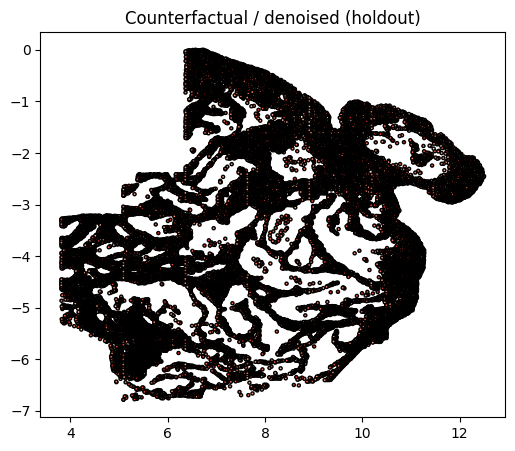

In [32]:
# visualize an example gene on holdout locations
plt.figure(figsize=(6,5))
gex = perturbed_counts[:, 5] if perturbed_counts is not None else np.zeros(pos_test.shape[0])
plt.scatter(loc_coords[test_mask,1], -loc_coords[test_mask,0], c=gex, cmap='Reds', edgecolor='k', s=5)
plt.title("Counterfactual / denoised (holdout)")
# ...existing code...

In [24]:
denoised_counts, _ = model.batching_denoise_counts(X=pos_train, 
                                                   sample_index=sample_indices_train, 
                                                   cell_atts=cell_atts_train, 
                                                   batch_size=batch_size, 
                                                   n_samples=25)

/data/a330d/projects/cellina-reproducibility/notebooks/../../CONCERT/src/concert_map.py:371: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  idx_t = torch.tensor(sample_index, dtype=torch.int)


In [25]:
# Counterfactuals for holdout cells:
# keep all other attributes same; set target tissue to the same tissue (no change)
# If you want to force a different target tissue, pass its code here (e.g. tissue_name_to_code['tumor'])
target_tissue_code_per_sample = cell_atts_test[:, 0]            
target_perturbation_per_sample = cell_atts_test[:, 1]           # keep batch same

perturbed_counts, _ = model.counterfactualPrediction(
    X=pos_test,
    sample_index=sample_indices_test,
    cell_atts=cell_atts_test,
    batch_size=batch_size,
    n_samples=25,
    perturb_cell_id=[],
    target_cell_tissue=target_tissue_code_per_sample,
    target_cell_perturbation=target_perturbation_per_sample,
)

/data/a330d/projects/cellina-reproducibility/notebooks/../../CONCERT/src/concert_map.py:543: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  idx_t = torch.tensor(sample_index, dtype=torch.int)


In [ ]:
perturbed_counts, _ = model.counterfactualPrediction(
    X=pos,
    sample_index=sample_indices_test,
    cell_atts=cell_atts_test,
    batch_size=batch_size,
    n_samples=25,
    perturb_cell_id=[],
    target_cell_tissue=target_tissue_code_per_sample,
    target_cell_perturbation=target_perturbation_per_sample,
)

In [75]:
def rescale_counts_per_cell(counts, desired_total=1e4, assume_logged=False, round_int=False, eps=1e-8):
    """
    Scale rows of `counts` so each row sums to `desired_total`.
    - counts: ndarray or scipy sparse (cells x genes)
    - desired_total: target row-sum (float)
    - assume_logged: if True, apply expm1 before scaling (counts are log1p)
    - round_int: if True, return integer counts (np.int32)
    """
    import numpy as np
    from scipy import sparse

    if sparse.issparse(counts):
        pc = counts.toarray().astype(float)
    else:
        pc = np.asarray(counts, dtype=float)

    if assume_logged:
        pc = np.expm1(pc)

    row_sums = pc.sum(axis=1)
    row_sums_safe = np.where(row_sums == 0, 1.0, row_sums)
    scales = desired_total / (row_sums_safe + eps)
    pc_scaled = pc * scales[:, None]

    if round_int:
        return np.rint(pc_scaled).astype(np.int32)
    return pc_scaled

In [ ]:
counts_per_k = 1e4
denoised_counts_scaled = rescale_counts_per_cell(denoised_counts, 
                                                  desired_total=counts_per_k)
perturbed_counts_scaled = rescale_counts_per_cell(perturbed_counts, 
                                                  desired_total=counts_per_k)

In [77]:
import numpy as np

# Boolean mask
holdout_mask = adata.obs["is_holdout"].values.astype(bool)

# Allocate full matrix
recon = np.zeros((adata.n_obs, denoised_counts_scaled.shape[1]))

# Fill correct rows
recon[~holdout_mask] = denoised_counts_scaled
recon[holdout_mask] = perturbed_counts_scaled

# Store in adata
adata.obsm["recon_x"] = recon

In [78]:
adata

AnnData object with n_obs × n_vars = 420694 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:04<00:00,  1.72it/s]
/tmp/ipykernel_3521651/962985815.py:133: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=8)


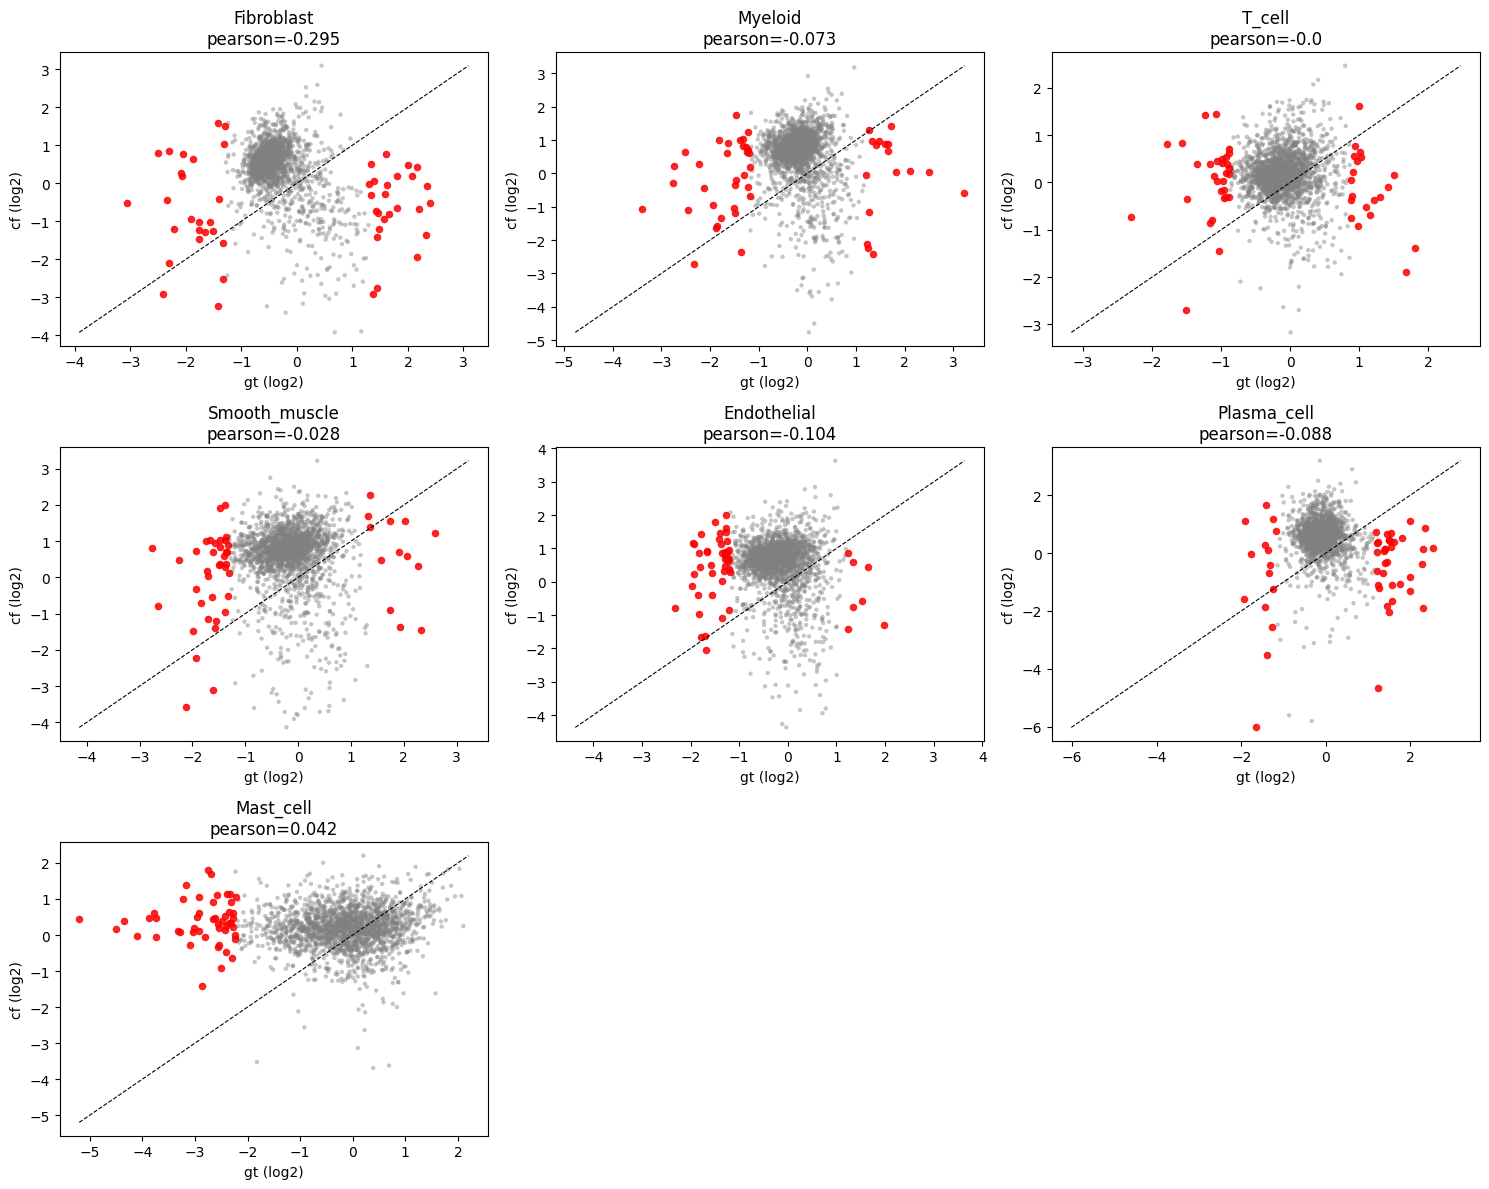

In [79]:
from tqdm import tqdm

from counterfactual_analysis import safe_log2_fold_change, _to_dense
from scipy.stats import pearsonr, spearmanr

normalize_counts = True
use_recon = False
k = 50

results = []
vectors = {}
cts = adata.obs[labels_key].unique()

for ct in tqdm(cts):
    if ct == 'Epithelial':
        continue

    adata_sub = adata[adata.obs[labels_key] == ct]
    groups = adata_sub.obs["is_holdout"].values
    var_names = np.asarray(adata.var_names)

    # masks
    mask_control = groups == False
    mask_target = groups == True
    mask_cf = groups == True

    def _normalize_counts(x, eps=1e-8):
        return x / (x.sum(axis=1, keepdims=True) + eps)

    # Counterfactuals/predictions are always model-generated
    recon_all = _to_dense(adata_sub.obsm.get("recon_x").copy())
    recon_all = np.log1p(recon_all)
    recon_all = (
        _normalize_counts(recon_all, eps=eps) if normalize_counts else recon_all
    )
    mean_cf = recon_all[mask_cf]
    mean_cf = mean_cf.mean(axis=0)

    # Control and target can be either from recon or raw counts
    X_all = (
        adata_sub.obsm.get("recon_x").copy()
        if use_recon
        else adata_sub.layers["counts"].copy()
    )
    X_all = _to_dense(X_all)  # ensure dense array
    X_all = np.log1p(X_all)
    X_all = _normalize_counts(X_all, eps=eps) if normalize_counts else X_all

    # compute group means (ensure arrays)
    mean_control = X_all[mask_control].mean(axis=0)
    mean_target = X_all[mask_target].mean(axis=0)

    # compute gt and cf: observed perturbed (target) minus real control, and counterfactual minus real control
    diff_method = safe_log2_fold_change

    try:
        gt_vec = diff_method(mean_target, mean_control, eps=eps)
        cf_vec = diff_method(mean_cf, mean_control, eps=eps)
    except Exception:
        # numeric issues: skip
        continue

    vectors[ct] = {"gt": gt_vec, "cf": cf_vec, "genes": var_names}

    # compute Pearson and Spearman on finite entries
    valid = np.isfinite(gt_vec) & np.isfinite(cf_vec)
    if (
        valid.sum() < 2
        or (np.nanstd(gt_vec[valid]) == 0)
        or (np.nanstd(cf_vec[valid]) == 0)
    ):
        pear = np.nan
        spearman = np.nan
    else:
        pear, _ = pearsonr(gt_vec[valid], cf_vec[valid])
        spearman, _ = spearmanr(gt_vec[valid], cf_vec[valid])

    results.append(
        {"celltype": ct, "pearson": pear, "spearman": spearman}
    )

plot = True
    # plotting: create multiplot grid with 3 columns per row, one scatter per cell type
if plot and len(results) > 0:
    import math

    ordered_cts = [r["celltype"] for r in results]
    n = len(ordered_cts)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False
    )
    axes_flat = axes.flatten()

    for i, ct in enumerate(ordered_cts):
        ax = axes_flat[i]
        gt_vec = vectors[ct]["gt"]
        cf_vec = vectors[ct]["cf"]
        var_names = vectors[ct]["genes"]

        valid = np.isfinite(gt_vec) & np.isfinite(cf_vec)
        # plot all genes (use valid mask for plotting extents)
        ax.scatter(
            gt_vec, cf_vec, s=10, alpha=0.45, color="gray", edgecolors="none"
        )
        # highlight top-k GT genes
        top_idx = np.argsort(-np.abs(gt_vec))[:k]
        ax.scatter(
            gt_vec[top_idx],
            cf_vec[top_idx],
            s=20,
            color="red",
            alpha=0.8,
        )

        # diagonal
        try:
            mn = np.nanmin([gt_vec[valid].min(), cf_vec[valid].min()])
            mx = np.nanmax([gt_vec[valid].max(), cf_vec[valid].max()])
        except Exception:
            mn, mx = 0, 1
        ax.plot([mn, mx], [mn, mx], color="black", linewidth=0.8, linestyle="--")

        # metrics for title
        res = next((r for r in results if r["celltype"] == ct), None)
        pear = res["pearson"] if res is not None else np.nan
        ax.set_title(
            f"{ct}\npearson={np.round(pear, 3) if not pd.isna(pear) else 'nan'}"
        )
        ax.set_xlabel(f"gt (log2)")
        ax.set_ylabel(f"cf (log2)")
        ax.legend(frameon=False, fontsize=8)

    # turn off any unused axes
    for j in range(n, nrows * ncols):
        axes_flat[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
a = sc.read_h5ad('/data2/a330d/datasets/crc/crc_242/Myeloid/cpa_recon_x.h5ad')

In [83]:
b = sc.read_h5ad('/data2/a330d/datasets/crc/crc_242/Myeloid/cellina_recon_x.h5ad')

In [85]:
a.X.sum(axis=1)

array([0.99999994, 1.        , 1.        , ..., 0.99999994, 0.9999999 ,
       1.        ], shape=(420694,), dtype=float32)

In [86]:
b.X.sum(axis=1)

array([1.       , 1.       , 1.       , ..., 1.       , 0.9999999,
       0.9999999], shape=(420694,), dtype=float32)